<a href="https://colab.research.google.com/github/augmented-vr/sample/blob/master/math_visualization_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

# 問題1の行列を用意する
matrix_a1 = np.array([
    [1, 2],
    [3, 4]
])
matrix_b1 = np.array([
    [5, 6],
    [7, 8]
])

# 足し算を計算して表示する (+記号で計算できる)
print("問題1(足し算)の答え:")
print(matrix_a1 + matrix_b1)

# 問題2の行列を用意する
matrix_a2 = np.array([
    [1, 2],
    [3, 4]
])
matrix_b2 = np.array([
    [2, 0],
    [1, 3]
])

# 行列の掛け算を計算して表示する (np.dot()を使います)
print("\n問題2(掛け算)の答え:")
print(np.dot(matrix_a2, matrix_b2))

問題1(足し算)の答え:
[[ 6  8]
 [10 12]]

問題2(掛け算)の答え:
[[ 4  6]
 [10 12]]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=53f999e5c0b62b763a0b61131ee6772c3e18c2ad31329db785706c6ab40ed941
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


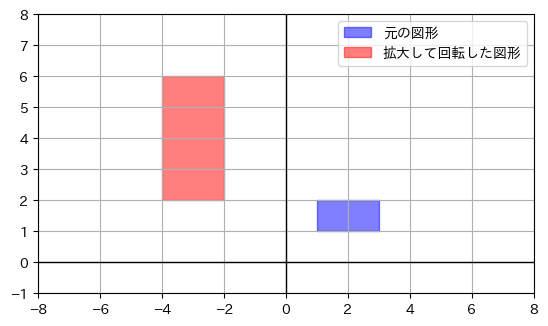

In [2]:
# 日本語表示のためのライブラリをインストール (Colab用)
!pip install japanize-matplotlib

import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib # 日本語化ライブラリの読み込み
from matplotlib.patches import Polygon

# 四角形の4つの頂点の座標(x, y)を用意する
# 計算の都合上、上がX座標のリスト、下がY座標のリストになるように2行4列の行列にします
points = np.array([
    [1, 3, 3, 1],
    [1, 1, 2, 2]
])

# 2倍に拡大する行列を用意する
scale_matrix = np.array([
    [2, 0],
    [0, 2]
])

# 90度(反時計回り)回転させる行列を用意する
rotate_matrix = np.array([
    [0, -1],
    [1, 0]
])

# np.dot()を使って、行列の掛け算で図形を変形させる
# まず2倍に拡大する
scaled_points = np.dot(scale_matrix, points)
# その結果をさらに90度回転させる
rotated_points = np.dot(rotate_matrix, scaled_points)

# グラフ描画の準備
fig, ax = plt.subplots()

# 元の図形を青色で描画する (転置 .Tをして形式を合わせる)
poly_original = Polygon(points.T, closed=True, color="blue", alpha=0.5, label="元の図形")
ax.add_patch(poly_original)

# 変形後の図形を赤色で描画する
poly_transformed = Polygon(rotated_points.T, closed=True, color="red", alpha=0.5, label="拡大して回転した図形")
ax.add_patch(poly_transformed)

# グラフの表示範囲と設定
ax.set_xlim(-8, 8)
ax.set_ylim(-1, 8)
ax.set_aspect("equal") # 図形が歪まないように縦横比を固定する
plt.grid(True)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.legend()
plt.show()

In [3]:
# 日本語表示のためのライブラリをインストール (Colab用)
!pip install japanize-matplotlib

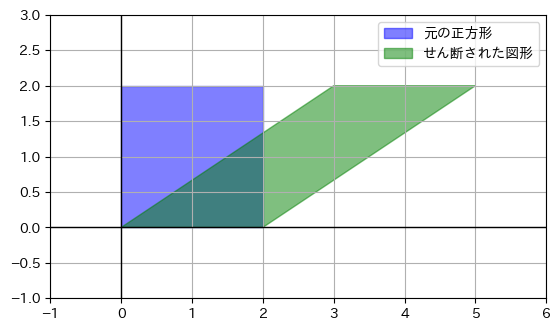

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib # 日本語化ライブラリの読み込み
from matplotlib.patches import Polygon

# 元の正方形の座標を用意する
points = np.array([
    [0, 2, 2, 0],
    [0, 0, 2, 2]
])

# x軸方向に斜めに歪ませる(せん断)行列を用意する (a = 1.5)
shear_matrix = np.array([
    [1, 1.5],
    [0, 1]
])

# np.dot()を使ってせん断を適用する
sheared_points = np.dot(shear_matrix, points)

# グラフ描画の準備
fig, ax = plt.subplots()

# 元の図形を青色で描画
ax.add_patch(Polygon(points.T, closed=True, color="blue", alpha=0.5, label="元の正方形"))

# 歪ませた図形を緑色で描画
ax.add_patch(Polygon(sheared_points.T, closed=True, color="green", alpha=0.5, label="せん断された図形"))

# グラフの表示設定
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 3)
ax.set_aspect("equal")
plt.grid(True)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.legend()
plt.show()

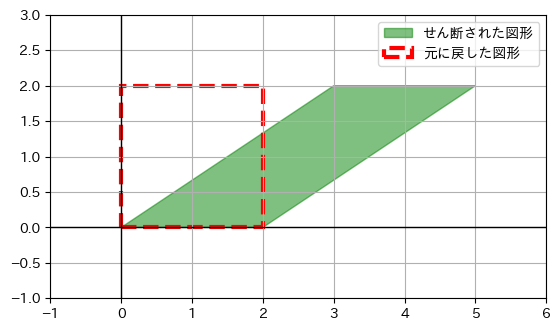

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib # 日本語化ライブラリの読み込み
from matplotlib.patches import Polygon

# 元の正方形の座標を用意する
points = np.array([
    [0, 2, 2, 0],
    [0, 0, 2, 2]
])

# X軸方向に斜めに歪ませる(せん断) (a = 1.5)
shear_matrix = np.array([
    [1, 1.5],
    [0, 1]
])

# np.dot()を使ってせん断を適用する
sheared_points = np.dot(shear_matrix, points)

# --- ここから逆行列の処理 ---
inverse_matrix = np.linalg.inv(shear_matrix)

# 歪んだ図形(sheared_points)に逆行列を掛けて、元に戻す
restored_points = np.dot(inverse_matrix, sheared_points)

# グラフ描画の準備
fig, ax = plt.subplots()

# 歪んだ図形を緑色で描画
ax.add_patch(Polygon(sheared_points.T, closed=True, color="green", alpha=0.5, label="せん断された図形"))

# 元に戻した図形を赤色の点線で描画 (元の青い正方形と同じ位置になるか確認)
ax.add_patch(Polygon(restored_points.T, closed=True, fill=False, edgecolor="red", linewidth=3, linestyle="--", label="元に戻した図形"))

# グラフの表示設定
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 3)
ax.set_aspect("equal")
plt.grid(True)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.legend()
plt.show()